In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()
print(data_matrix)
print(f"shape: {data_matrix.shape}")

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [2]:
max_values=df[selected_columns].max()
min_values=df[selected_columns].min()

initial_centroids=np.random.uniform(min_values, max_values, (3,4))
print(initial_centroids)

[[5.19377734 2.03441215 5.85043709 2.03651201]
 [4.96668812 2.20460069 4.15057855 0.28537645]
 [5.53979519 2.3455228  5.75835276 0.80588632]]


In [3]:
def euclidean_distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

In [4]:
cluster_assignments = np.zeros(data_matrix.shape[0])
for i in range(data_matrix.shape[0]):
    distances = np.array([euclidean_distance(data_matrix[i], centroid) for centroid in initial_centroids])
    cluster_assignments[i] = np.argmin(distances)
print(cluster_assignments)

cluster_assignments=np.array(cluster_assignments)

for i in range(3):
    print(f"Cluster {i}: has {np.sum(cluster_assignments==i)} points")

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 2. 2. 2. 1. 2. 1. 2. 1. 2. 1. 1. 1. 1. 2. 1. 2. 2. 1. 2. 1. 2. 1.
 2. 2. 2. 2. 2. 2. 2. 1. 1. 1. 1. 2. 1. 2. 2. 2. 1. 1. 1. 2. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 0. 2. 2. 0. 2. 1. 2. 2. 0. 2. 0. 0. 0. 0. 0. 2. 2. 0. 2.
 0. 0. 2. 2. 0. 2. 2. 2. 0. 2. 2. 2. 0. 2. 2. 0. 0. 2. 2. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 2.]
Cluster 0: has 26 points
Cluster 1: has 78 points
Cluster 2: has 46 points


In [5]:
step=1
for i in range(step):
    for j in range(3):
        points_in_cluster = data_matrix[cluster_assignments == j]
        if len(points_in_cluster) > 0:
            initial_centroids[j] = np.mean(points_in_cluster, axis=0)
    for k in range(data_matrix.shape[0]):
        distances = np.array([euclidean_distance(data_matrix[k], centroid) for centroid in initial_centroids])
        cluster_assignments[k] = np.argmin(distances)
    for i in range(3):
        print(f"Cluster {i}: has {np.sum(cluster_assignments==i)} points")

Cluster 0: has 31 points
Cluster 1: has 59 points
Cluster 2: has 60 points


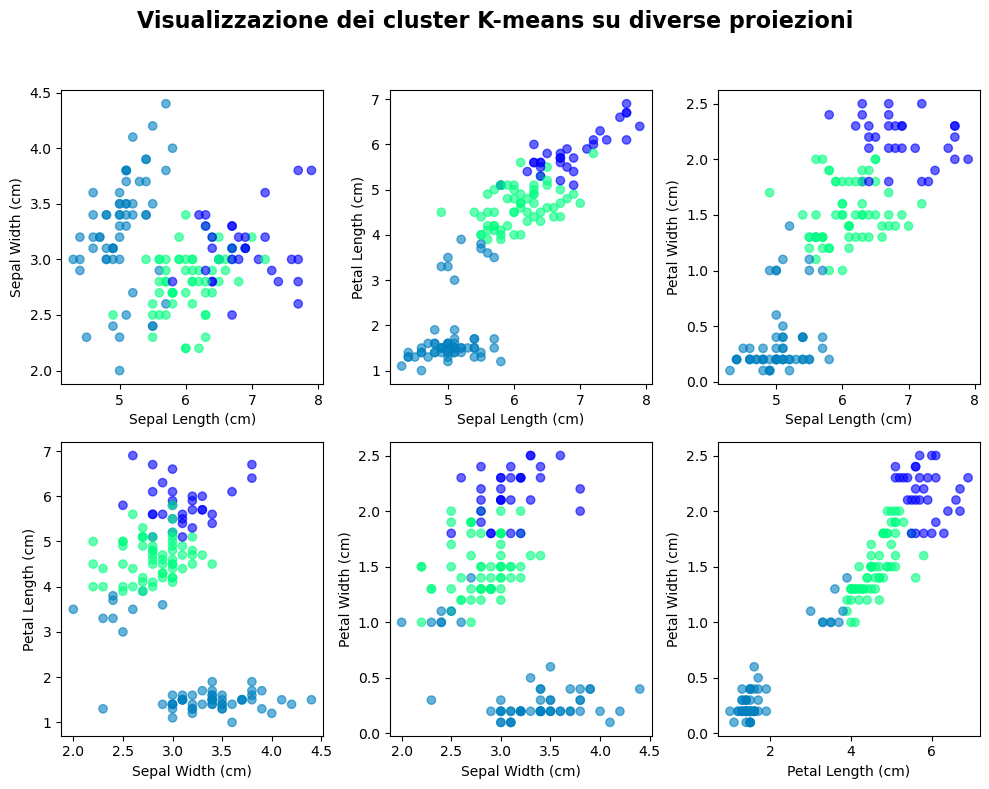

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 8))  # 2 righe, 3 colonne

# Scatter 1: SepalLength vs SepalWidth
axes[0, 0].scatter(data_matrix[:,0], data_matrix[:,1], c=cluster_assignments, cmap='winter', alpha=0.6)
axes[0, 0].set_xlabel("Sepal Length (cm)")
axes[0, 0].set_ylabel("Sepal Width (cm)")

# Scatter 2: SepalLength vs PetalLength
axes[0, 1].scatter(data_matrix[:,0], data_matrix[:,2], c=cluster_assignments, cmap='winter', alpha=0.6)
axes[0, 1].set_xlabel("Sepal Length (cm)")
axes[0, 1].set_ylabel("Petal Length (cm)")

# Scatter 3: SepalLength vs PetalWidth
axes[0, 2].scatter(data_matrix[:,0], data_matrix[:,3], c=cluster_assignments, cmap='winter', alpha=0.6)
axes[0, 2].set_xlabel("Sepal Length (cm)")
axes[0, 2].set_ylabel("Petal Width (cm)")

# Scatter 4: SepalWidth vs PetalLength
axes[1, 0].scatter(data_matrix[:,1], data_matrix[:,2], c=cluster_assignments, cmap='winter', alpha=0.6)
axes[1, 0].set_xlabel("Sepal Width (cm)")
axes[1, 0].set_ylabel("Petal Length (cm)")

# Scatter 5: SepalWidth vs PetalWidth
axes[1, 1].scatter(data_matrix[:,1], data_matrix[:,3], c=cluster_assignments, cmap='winter', alpha=0.6)
axes[1, 1].set_xlabel("Sepal Width (cm)")
axes[1, 1].set_ylabel("Petal Width (cm)")

# Scatter 6: PetalLength vs PetalWidth
axes[1, 2].scatter(data_matrix[:,2], data_matrix[:,3], c=cluster_assignments, cmap='winter', alpha=0.6)
axes[1, 2].set_xlabel("Petal Length (cm)")
axes[1, 2].set_ylabel("Petal Width (cm)")

# Titolo complessivo
fig.suptitle("Visualizzazione dei cluster K-means su diverse proiezioni", fontsize=16, fontweight='bold')

# Ottimizza layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<h3>Purity index</h3>

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix

def purity_score(y_true, y_pred):
    """
    Calcola la purity tra etichette vere (y_true) e assegnazioni di clustering (y_pred).
    
    Parameters:
    - y_true: array-like, etichette reali
    - y_pred: array-like, etichette di clustering
    
    Returns:
    - purity: float, valore tra 0 e 1
    """
    # Matrice di contingenza: righe = classi vere, colonne = cluster
    contingency_matrix = confusion_matrix(y_true, y_pred)
    
    # Somma dei massimi per ogni colonna (cluster)
    max_per_cluster = np.max(contingency_matrix, axis=0)
    
    # Purezza = somma dei massimi / totale dei campioni
    purity = np.sum(max_per_cluster) / np.sum(contingency_matrix)
    
    return purity

print("Clustering")
print(cluster_assignments)

# Let's take the ground truth from the database
ground_truth = np.array([0]*50 + [1]*50 + [2]*50)
print(ground_truth)
print("Purity score of k-means:",purity_score(ground_truth,cluster_assignments))
print(confusion_matrix(ground_truth,cluster_assignments))

Clustering
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 2. 2. 2. 2. 2. 2. 2. 1. 2. 1. 1. 2. 2. 2. 1. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 2.
 2. 2. 1. 2. 0. 2. 0. 0. 0. 0. 2. 0. 0. 0. 2. 2. 0. 2. 0. 0. 2. 0. 0. 2.
 0. 2. 0. 2. 0. 0. 2. 2. 0. 2. 0. 0. 0. 2. 2. 0. 0. 0. 2. 0. 0. 0. 2. 0.
 0. 0. 2. 2. 0. 2.]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Purity score of k-means: 0.8133333333333334
[[ 0 50  0]
 [ 0  9 41]
 [31  0 19]]


In [8]:
import numpy as np

step = 1
it = np.arange(1, 16)
purity = np.zeros(15)

# Assicurati che questi siano definiti prima:
# - data_matrix: array (n_samples, n_features)
# - min_values, max_values: array (n_features,) per i limiti di inizializzazione
# - ground_truth: etichette vere (n_samples,)
# - euclidean_distance: funzione di distanza
# - cluster_assignments: inizializzazione (es. np.zeros(n_samples, dtype=int))
random_centroids=np.random.uniform(min_values, max_values, (3, 4))
for t in range(15):
    # Inizializzazione casuale dei centroidi
    initial_centroids = random_centroids

    # Prima assegnazione dei punti ai cluster
    for k in range(data_matrix.shape[0]):
        distances = np.array([
            euclidean_distance(data_matrix[k], centroid)
            for centroid in initial_centroids
        ])
        cluster_assignments[k] = np.argmin(distances)

    # Iterazioni di aggiornamento (step volte)
    for i in range(step):
        # Aggiorna i centroidi
        for j in range(3):
            points_in_cluster = data_matrix[cluster_assignments == j]
            if len(points_in_cluster) > 0:
                initial_centroids[j] = np.mean(points_in_cluster, axis=0)

        # Riassegna i punti ai cluster
        for k in range(data_matrix.shape[0]):
            distances = np.array([
                euclidean_distance(data_matrix[k], centroid)
                for centroid in initial_centroids
            ])
            cluster_assignments[k] = np.argmin(distances)

    # Calcola la purity
    purity[t] = purity_score(ground_truth, cluster_assignments)
    step+=1
print("Purity:", purity)
print("Iterazioni:", it)


Purity: [0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 0.66666667 0.66666667 0.66666667]
Iterazioni: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


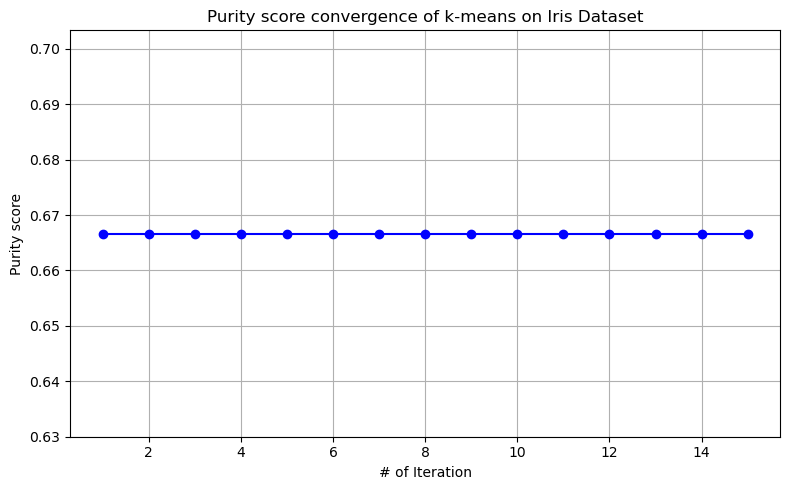

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(it, purity, marker='o', linestyle='-', color='blue')
plt.title("Purity score convergence of k-means on Iris Dataset")
plt.xlabel("# of Iteration")
plt.ylabel("Purity score")
plt.grid(True)
plt.tight_layout()
plt.savefig("purity_vs_iteration.pdf", format="pdf")
plt.show()

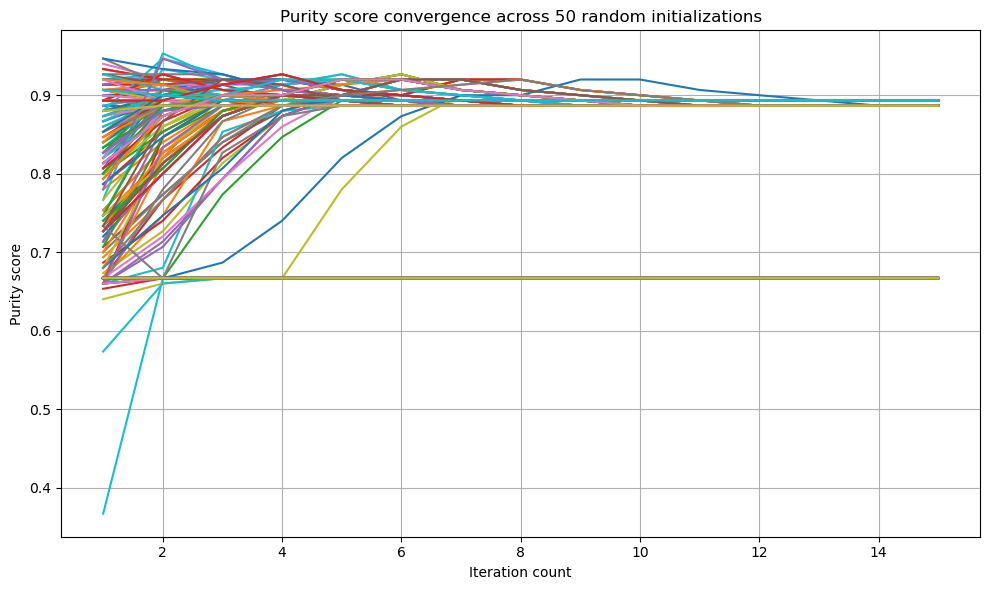

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
n_runs = 200
n_iterations = 15
it = np.arange(1, n_iterations + 1)

# Lista per salvare tutte le curve di purity
all_purities = []

for run in range(n_runs):
    step = 1
    purity = np.zeros(n_iterations)

    # Centroidi iniziali casuali per questo run
    random_centroids = np.random.uniform(min_values, max_values, (3, 4))

    # Inizializza cluster_assignments per ogni run
    cluster_assignments = np.zeros(data_matrix.shape[0], dtype=int)

    for t in range(n_iterations):
        initial_centroids = random_centroids.copy()

        # Prima assegnazione
        for k in range(data_matrix.shape[0]):
            distances = np.array([
                euclidean_distance(data_matrix[k], centroid)
                for centroid in initial_centroids
            ])
            cluster_assignments[k] = np.argmin(distances)

        # Aggiornamenti
        for i in range(step):
            for j in range(3):
                points_in_cluster = data_matrix[cluster_assignments == j]
                if len(points_in_cluster) > 0:
                    initial_centroids[j] = np.mean(points_in_cluster, axis=0)

            for k in range(data_matrix.shape[0]):
                distances = np.array([
                    euclidean_distance(data_matrix[k], centroid)
                    for centroid in initial_centroids
                ])
                cluster_assignments[k] = np.argmin(distances)

        purity[t] = purity_score(ground_truth, cluster_assignments)
        step += 1

    all_purities.append(purity)

# 🎨 Plot delle 10 curve senza etichette
plt.figure(figsize=(10, 6))
for purity_curve in all_purities:
    plt.plot(it, purity_curve)

plt.title("Purity score convergence across 50 random initializations")
plt.xlabel("Iteration count")
plt.ylabel("Purity score")
plt.grid(True)
plt.tight_layout()

plt.show()


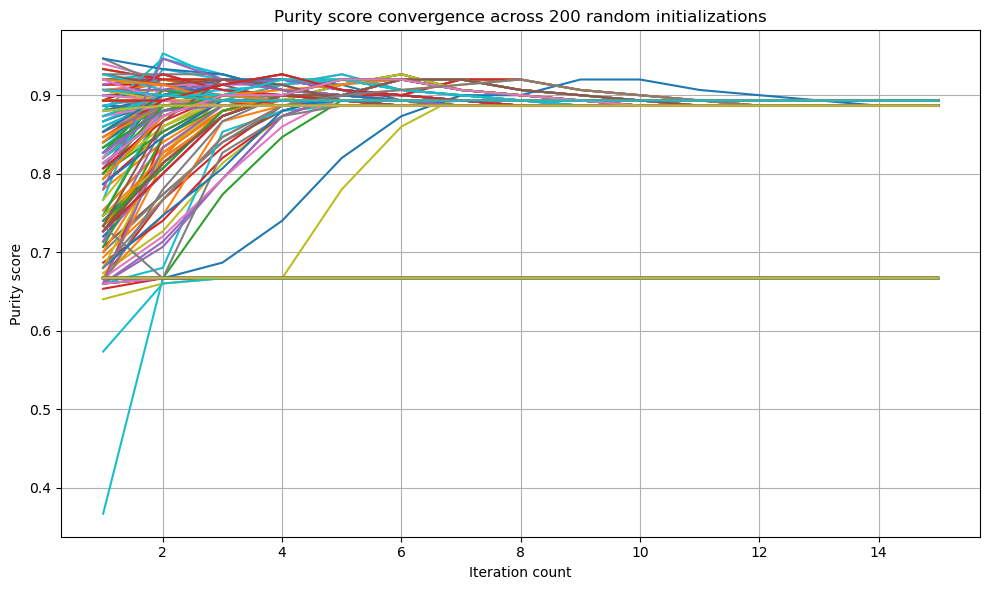

In [11]:
plt.figure(figsize=(10, 6))
for purity_curve in all_purities:
    plt.plot(it, purity_curve)

plt.title("Purity score convergence across 200 random initializations")
plt.xlabel("Iteration count")
plt.ylabel("Purity score")
plt.grid(True)
plt.tight_layout()
plt.savefig("purity_vs_iteration_random_200.pdf", format="pdf")

plt.show()
